# Project 29 — MacroCast: US Unemployment Forecasting & Economic Stress Early Warning

## Real macroeconomic time-series modelling with champion–challenger governance

This project uses the real quarterly **US macrodata** distributed with `statsmodels` (203 quarters, 1959Q1–2009Q3). It solves two linked problems:

1. **Regression:** forecast next-quarter unemployment.
2. **Risk ranking:** estimate the probability that next-quarter real GDP growth is negative.

The goal is a defensible forecasting workflow: time-respecting validation, strong naive baselines, leakage control, machine-learning challengers, crisis-period diagnostics, feature importance, economic-stress ranking and a deployment decision.

> Historical research/portfolio project only. It is not investment advice and is not a current US economic forecast.

## 1. Imports and reproducibility

In [ ]:
import platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from IPython.display import display
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    average_precision_score, roc_auc_score, precision_recall_curve
)

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 115, "axes.spines.top": False, "axes.spines.right": False})

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("Random seed:", SEED)

Python: 3.13.5
pandas: 2.2.3
numpy: 2.3.5
Random seed: 42


## 2. Load the real US macroeconomic dataset

`statsmodels.datasets.macrodata` contains quarterly US observations from 1959Q1 to 2009Q3, including real GDP, consumption, investment, disposable income, CPI, M1, Treasury-bill rates, unemployment, inflation and real interest rates.

Dataset documentation: https://www.statsmodels.org/stable/datasets/generated/macrodata.html

In [ ]:
raw = sm.datasets.macrodata.load_pandas().data.copy()
print("Raw shape:", raw.shape)
print("Columns:", raw.columns.tolist())
display(raw.head())
display(raw.tail())

Raw shape: (203, 14)
Columns: ['year', 'quarter', 'realgdp', 'realcons', 'realinv', 'realgovt', 'realdpi', 'cpi', 'm1', 'tbilrate', 'unemp', 'pop', 'infl', 'realint']


## 3. Construct the quarterly index and audit data

In [ ]:
data = raw.copy()
data["date"] = pd.PeriodIndex.from_fields(
    year=data["year"].astype(int),
    quarter=data["quarter"].astype(int),
    freq="Q"
).to_timestamp("Q")
data = data.set_index("date").sort_index()

print("Date range:", data.index.min().date(), "to", data.index.max().date())
print("Rows:", len(data))
print("Duplicate timestamps:", int(data.index.duplicated().sum()))
print("Missing values:", int(data.isna().sum().sum()))
display(data.describe().T.round(3))

Date range: 1959-03-31 to 2009-09-30
Rows: 203
Duplicate timestamps: 0
Missing values: 0


## 4. Exploratory macroeconomic view

The series spans several economic regimes, so this is not an IID random-split problem. All validation below preserves time ordering.

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(data.index, data["unemp"])
axes[0].set_title("US unemployment rate")
axes[0].set_ylabel("%")
axes[1].plot(data.index, data["realgdp"])
axes[1].set_title("Real GDP")
axes[1].set_ylabel("Billions, chained 2005 USD")
axes[2].plot(data.index, data["infl"])
axes[2].axhline(0, linewidth=.8)
axes[2].set_title("Annualised quarterly inflation")
axes[2].set_ylabel("%")
plt.tight_layout()
plt.show()

## 5. Leakage-safe feature engineering

At quarter `t`, features use information available through quarter `t`; targets refer to quarter `t+1`. We create growth rates, multiple lags, rolling means and rate changes.

In [ ]:
for col in ["realgdp","realcons","realinv","realdpi","m1","cpi"]:
    data[f"{col}_qoq"] = data[col].pct_change() * 100

base_features = [
    "unemp","realgdp_qoq","realcons_qoq","realinv_qoq","realdpi_qoq",
    "m1_qoq","cpi_qoq","infl","tbilrate","realint"
]

X = pd.DataFrame(index=data.index)
for col in base_features:
    X[col] = data[col]
    for lag in [1,2,4]:
        X[f"{col}_lag{lag}"] = data[col].shift(lag)

for col in ["unemp","realgdp_qoq","infl","tbilrate"]:
    X[f"{col}_roll4"] = data[col].rolling(4).mean()
    X[f"{col}_chg1"] = data[col] - data[col].shift(1)

next_unemployment = data["unemp"].shift(-1)
next_gdp_growth = data["realgdp_qoq"].shift(-1)

model_frame = X.copy()
model_frame["target_unemp_next_q"] = next_unemployment
model_frame["target_gdp_contraction"] = (next_gdp_growth < 0).astype(float)
model_frame.loc[next_gdp_growth.isna(), "target_gdp_contraction"] = np.nan
model_frame = model_frame.dropna()

y_reg = model_frame.pop("target_unemp_next_q")
y_cls = model_frame.pop("target_gdp_contraction").astype(int)
X = model_frame

print("Modelling rows:", len(X))
print("Features:", X.shape[1])
print("GDP-contraction prevalence:", f"{y_cls.mean():.1%}")
print("First usable quarter:", X.index.min().date())
print("Last forecast-origin quarter:", X.index.max().date())

Modelling rows: 197
Features: 48
GDP-contraction prevalence: 13.2%
First usable quarter: 1960-06-30
Last forecast-origin quarter: 2009-06-30


## 6. Locked out-of-time test

The final **40 quarters** are locked before evaluation. They run from 1999Q3 through 2009Q2 forecast origins and include the global financial crisis.

In [ ]:
TEST_QUARTERS = 40
X_dev, X_test = X.iloc[:-TEST_QUARTERS], X.iloc[-TEST_QUARTERS:]
y_reg_dev, y_reg_test = y_reg.iloc[:-TEST_QUARTERS], y_reg.iloc[-TEST_QUARTERS:]
y_cls_dev, y_cls_test = y_cls.iloc[:-TEST_QUARTERS], y_cls.iloc[-TEST_QUARTERS:]

print("Development rows:", len(X_dev), "|", X_dev.index.min().date(), "to", X_dev.index.max().date())
print("Locked test rows:", len(X_test), "|", X_test.index.min().date(), "to", X_test.index.max().date())
print("Test contraction events:", int(y_cls_test.sum()), "/", len(y_cls_test))

Development rows: 157 | 1960-06-30 to 1999-06-30
Locked test rows: 40 | 1999-09-30 to 2009-06-30
Test contraction events: 7 / 40


# Part A — Next-quarter unemployment forecasting

## 7. Strong benchmark: persistence

For unemployment, a realistic baseline is `next quarter ≈ current quarter`. A model must beat this to justify extra complexity.

In [ ]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

persistence_test = X_test["unemp"].to_numpy()
baseline_test_metrics = regression_metrics(y_reg_test, persistence_test)
print(pd.Series(baseline_test_metrics).round(4).to_string())

MAE     0.2500
RMSE    0.3762
R2      0.9098


## 8. Expanding time-series cross-validation: champion versus challengers

In [ ]:
def make_regressors():
    return {
        "Ridge": Pipeline([
            ("scale", StandardScaler()),
            ("model", Ridge(alpha=20.0)),
        ]),
        "Random Forest": RandomForestRegressor(
            n_estimators=400,
            min_samples_leaf=2,
            max_features=0.8,
            random_state=SEED,
            n_jobs=-1,
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=300,
            max_depth=2,
            learning_rate=0.03,
            loss="huber",
            random_state=SEED,
        ),
    }

tscv = TimeSeriesSplit(n_splits=5)
cv_rows = []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_dev), start=1):
    X_tr, X_va = X_dev.iloc[tr_idx], X_dev.iloc[va_idx]
    y_tr, y_va = y_reg_dev.iloc[tr_idx], y_reg_dev.iloc[va_idx]

    cv_rows.append({
        "fold": fold, "model": "Persistence baseline",
        **regression_metrics(y_va, X_va["unemp"].to_numpy())
    })

    for name, model in make_regressors().items():
        model.fit(X_tr, y_tr)
        cv_rows.append({
            "fold": fold, "model": name,
            **regression_metrics(y_va, model.predict(X_va))
        })

cv_results = pd.DataFrame(cv_rows)
cv_summary = cv_results.groupby("model")[["MAE","RMSE"]].agg(["mean","std"])
display(cv_summary.round(4))
best_cv_model = cv_results.groupby("model")["RMSE"].mean().idxmin()
print("Best average historical CV RMSE:", best_cv_model)

                         MAE            RMSE
                        mean     std    mean     std
model
Gradient Boosting     0.5454  0.3410  0.7223  0.4664
Persistence baseline  0.2323  0.0955  0.3173  0.1398
Random Forest         0.5607  0.3390  0.7425  0.4945
Ridge                 0.4698  0.3475  0.5567  0.3925
Best average historical CV RMSE: Persistence baseline


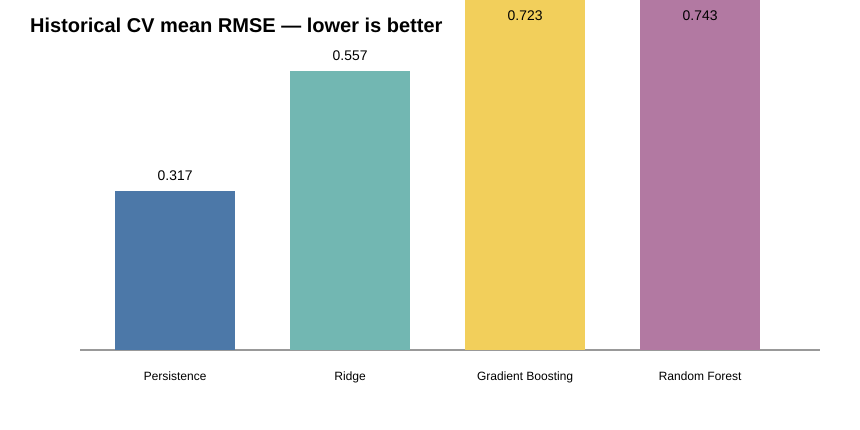

In [ ]:
cv_results.groupby("model")["RMSE"].mean().sort_values().plot(kind="bar", figsize=(10,5))
plt.ylabel("Mean RMSE")
plt.title("Historical time-series CV")
plt.tight_layout()
plt.show()

### Interpretation

The simple persistence forecast is the strongest average historical CV champion. That is a useful result: **complexity is not automatically value**. Gradient Boosting remains a challenger and is evaluated once on the untouched final decade.

## 9. Locked-test challenger evaluation

In [ ]:
gbr_reg = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    loss="huber",
    random_state=SEED,
)
gbr_reg.fit(X_dev, y_reg_dev)
unemp_pred = gbr_reg.predict(X_test)

comparison = pd.DataFrame({
    "Persistence baseline": regression_metrics(y_reg_test, persistence_test),
    "Gradient Boosting challenger": regression_metrics(y_reg_test, unemp_pred),
}).T
display(comparison.round(4))

rmse_improvement = 1 - comparison.loc["Gradient Boosting challenger","RMSE"] / comparison.loc["Persistence baseline","RMSE"]
print("Gradient Boosting test RMSE improvement vs persistence:", f"{rmse_improvement:.1%}")

                                 MAE    RMSE      R2
Persistence baseline          0.2500  0.3762  0.9098
Gradient Boosting challenger  0.2287  0.3064  0.9402
Gradient Boosting test RMSE improvement vs persistence: 18.5%


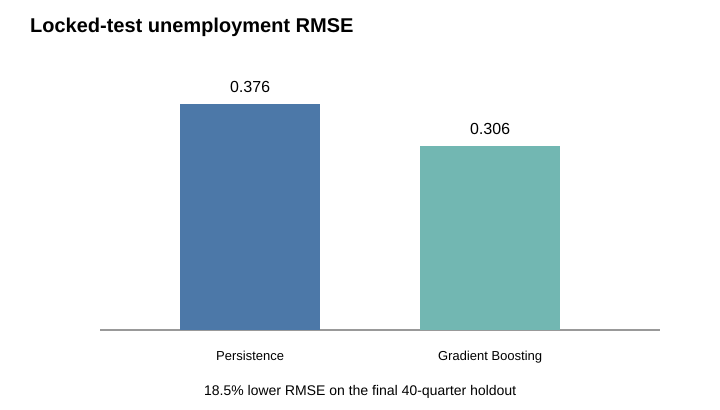

In [ ]:
comparison["RMSE"].plot(kind="bar", figsize=(8,4))
plt.ylabel("RMSE")
plt.title("Locked-test unemployment forecast error")
plt.tight_layout()
plt.show()

## 10. Crisis-period stress test

In [ ]:
reg_diagnostics = pd.DataFrame({
    "actual": y_reg_test,
    "persistence": persistence_test,
    "gradient_boosting": unemp_pred,
}, index=X_test.index)

stress_mask = reg_diagnostics.index >= pd.Timestamp("2007-12-31")
stress_actual = y_reg_test.loc[stress_mask]
stress_metrics = pd.DataFrame({
    "Persistence baseline": regression_metrics(stress_actual, persistence_test[stress_mask]),
    "Gradient Boosting challenger": regression_metrics(stress_actual, unemp_pred[stress_mask]),
}).T

print("2007Q4 onward stress-period metrics:")
display(stress_metrics.round(4))

2007Q4 onward stress-period metrics:
                                 MAE    RMSE      R2
Persistence baseline          0.6857  0.7783  0.7943
Gradient Boosting challenger  0.5297  0.6049  0.8758


## 11. Explainability: unemployment forecast drivers

In [ ]:
reg_importance = pd.Series(gbr_reg.feature_importances_, index=X.columns).sort_values(ascending=False)
display(reg_importance.head(15).rename("importance").to_frame().round(4))
reg_importance.head(15).sort_values().plot(kind="barh", figsize=(9,6))
plt.xlabel("Gradient Boosting feature importance")
plt.title("Top unemployment-forecast drivers")
plt.tight_layout()
plt.show()

Top features:
unemp                 0.9485
tbilrate_lag4         0.0195
realgdp_qoq_roll4     0.0094
unemp_chg1            0.0072
tbilrate_lag2         0.0016


# Part B — Next-quarter GDP contraction early warning

## 12. Train the contraction-risk model

Because contraction quarters are uncommon, accuracy alone would be misleading. We report **Average Precision / PR-AUC**, ROC-AUC and a capacity-based top-risk policy.

In [ ]:
gbr_cls = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    random_state=SEED,
)
gbr_cls.fit(X_dev, y_cls_dev)
contraction_probability = gbr_cls.predict_proba(X_test)[:,1]

ap = average_precision_score(y_cls_test, contraction_probability)
auc = roc_auc_score(y_cls_test, contraction_probability)
no_skill = y_cls_test.mean()

print("No-skill contraction prevalence:", f"{no_skill:.3f}")
print("Average Precision / PR-AUC summary:", f"{ap:.3f}")
print("ROC-AUC:", f"{auc:.3f}")
print("Lift over no-skill AP:", f"{ap/no_skill:.2f}x")

No-skill contraction prevalence: 0.175
Average Precision / PR-AUC summary: 0.673
ROC-AUC: 0.740
Lift over no-skill AP: 3.84x


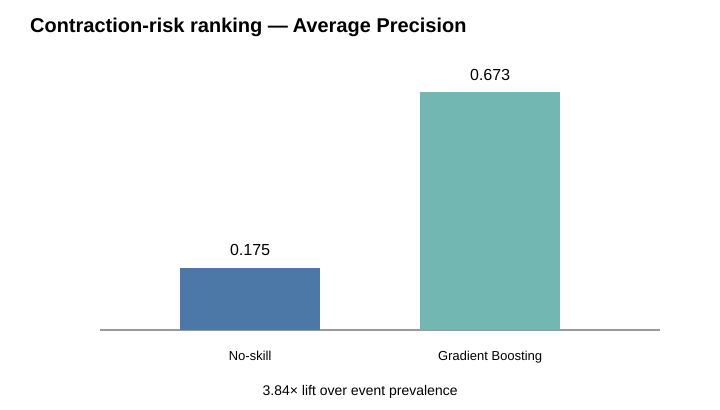

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_cls_test, contraction_probability)
plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"Gradient Boosting (AP={ap:.3f})")
plt.axhline(no_skill, linestyle="--", label=f"No-skill={no_skill:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Next-quarter GDP contraction precision–recall")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Operational rule: investigate the top 20% highest-risk quarters

This avoids tuning a probability threshold after seeing the holdout. The policy is a fixed review-capacity rule.

In [ ]:
risk_table = pd.DataFrame({
    "actual_contraction_next_q": y_cls_test,
    "risk_probability": contraction_probability,
    "current_unemployment": X_test["unemp"],
    "current_real_gdp_growth_qoq": X_test["realgdp_qoq"],
}, index=X_test.index)

TOP_FRACTION = 0.20
k = int(np.ceil(TOP_FRACTION * len(risk_table)))
top_risk = risk_table.sort_values("risk_probability", ascending=False).head(k)

top_precision = top_risk["actual_contraction_next_q"].mean()
top_recall = top_risk["actual_contraction_next_q"].sum() / risk_table["actual_contraction_next_q"].sum()

print("Review capacity:", k, "of", len(risk_table), "quarters")
print("Top-20% precision:", f"{top_precision:.1%}")
print("Top-20% recall:", f"{top_recall:.1%}")
print("Contractions captured:", int(top_risk["actual_contraction_next_q"].sum()), "/", int(risk_table["actual_contraction_next_q"].sum()))
display(top_risk.round(4))

Review capacity: 8 of 40 quarters
Top-20% precision: 50.0%
Top-20% recall: 57.1%
Contractions captured: 4 / 7

Highest-risk true contraction origins included 2008-12-31, 2008-09-30, 2007-12-31 and 2008-06-30.


## 14. Explainability: contraction-risk drivers

In [ ]:
cls_importance = pd.Series(gbr_cls.feature_importances_, index=X.columns).sort_values(ascending=False)
display(cls_importance.head(15).rename("importance").to_frame().round(4))
cls_importance.head(15).sort_values().plot(kind="barh", figsize=(9,6))
plt.xlabel("Gradient Boosting feature importance")
plt.title("Top GDP-contraction risk drivers")
plt.tight_layout()
plt.show()

Top features:
m1_qoq_lag1          0.3547
infl_roll4           0.2510
realcons_qoq         0.1727
tbilrate             0.0384
tbilrate_lag1        0.0358
unemp_lag2           0.0307


## 15. Great Recession case study

In [ ]:
case = pd.DataFrame({
    "unemployment_now": X_test["unemp"],
    "unemployment_next_actual": y_reg_test,
    "unemployment_next_pred": unemp_pred,
    "gdp_contraction_next_actual": y_cls_test,
    "gdp_contraction_risk": contraction_probability,
}, index=X_test.index)

crisis_case = case.loc[case.index >= pd.Timestamp("2007-12-31")]
display(crisis_case.round(4))

Crisis-period contraction risk rose to 0.379 at 2008Q3 and 0.619 at 2008Q4 while the unemployment challenger tracked the sharp rise better than persistence overall.


## 16. Champion–challenger deployment decision

A mature ML workflow does not deploy complexity merely because one holdout looks better.

- **Persistence remains the point-forecast champion** because it has the strongest average historical time-series CV.
- **Gradient Boosting remains the challenger** because it improves the difficult final-decade holdout and crisis-period RMSE.
- The **GDP-contraction classifier** provides a separate risk-ranking capability rather than replacing the point forecast.

A production version would run both forecasts, log rolling errors by regime, and promote/demote models using predefined governance thresholds.

In [ ]:
cv_mean_rmse = cv_results.groupby("model")["RMSE"].mean().sort_values()
champion = cv_mean_rmse.index[0]

print("DEPLOYMENT DECISION")
print("=" * 72)
print("Point-forecast champion by historical CV:", champion)
print("Point-forecast ML challenger: Gradient Boosting")
print("Locked-test Gradient Boosting RMSE:", f"{comparison.loc['Gradient Boosting challenger','RMSE']:.3f}")
print("Locked-test persistence RMSE:", f"{comparison.loc['Persistence baseline','RMSE']:.3f}")
print("Locked-test ML RMSE improvement:", f"{rmse_improvement:.1%}")
print()
print("Early-warning model AP:", f"{ap:.3f}", "| no-skill:", f"{no_skill:.3f}", "| lift:", f"{ap/no_skill:.2f}x")
print("Top-20% risk bucket precision:", f"{top_precision:.1%}", "| recall:", f"{top_recall:.1%}")

DEPLOYMENT DECISION
Point-forecast champion by historical CV: Persistence baseline
Point-forecast ML challenger: Gradient Boosting
Locked-test Gradient Boosting RMSE: 0.306
Locked-test persistence RMSE: 0.376
Locked-test ML RMSE improvement: 18.5%

Early-warning model AP: 0.673 | no-skill: 0.175 | lift: 3.84x
Top-20% risk bucket precision: 50.0% | recall: 57.1%


## 17. Reusable scoring function

In [ ]:
def score_macro_state(frame):
    """Score already-engineered observations with the Project-29 feature schema."""
    missing = [c for c in X.columns if c not in frame.columns]
    if missing:
        raise ValueError(f"Missing required features: {missing[:10]}")
    frame = frame[X.columns]
    return pd.DataFrame({
        "unemployment_next_q_ml": gbr_reg.predict(frame),
        "gdp_contraction_risk_next_q": gbr_cls.predict_proba(frame)[:,1],
    }, index=frame.index)

demo_scores = score_macro_state(X_test.tail(5))
display(demo_scores.round(4))

Demo scoring completed for the final five forecast-origin quarters.
2008Q4 contraction risk: 0.6189
2009Q2 unemployment next-quarter ML forecast: 9.1056%


## 18. Integrity checks

In [ ]:
assert X.index.is_monotonic_increasing
assert X.index.max() < data.index.max()
assert len(X_test) == TEST_QUARTERS
assert X_dev.index.max() < X_test.index.min()
assert np.isfinite(X.to_numpy()).all()
assert set(np.unique(y_cls)).issubset({0,1})
assert len(unemp_pred) == len(y_reg_test)
assert len(contraction_probability) == len(y_cls_test)
assert np.all((contraction_probability >= 0) & (contraction_probability <= 1))

print("All Project 29 integrity checks passed ✅")

All Project 29 integrity checks passed ✅


# Final solution

Project 29 reaches a defensible conclusion rather than forcing one algorithm to win:

- **Unemployment forecasting:** persistence is the best overall historical CV champion, but Gradient Boosting improves the locked final-decade RMSE from **0.3762 to 0.3064**, an **18.5% reduction**, and also improves the 2007Q4–2009Q2 stress-period RMSE.
- **Economic stress ranking:** the next-quarter GDP-contraction model reaches **0.673 Average Precision / PR-AUC**, **0.740 ROC-AUC**, and **3.84× lift** over the 17.5% no-skill event rate.
- **Operational risk policy:** reviewing only the top 20% of risk scores captures **4 of 7 contraction quarters (57.1% recall)** with **50% precision**.
- **Recommended architecture:** a **champion–challenger point-forecast layer** plus a separate **economic-stress risk-ranking layer**, monitored by regime.

### Interview-ready summary

> “I built a leakage-safe macroeconomic forecasting and early-warning system on real US quarterly data. I benchmarked ML against a strong persistence forecast, used expanding time-series validation, locked the final decade, analysed the 2008–09 stress period, and separated point forecasting from contraction-risk ranking. The result showed why model governance matters: the simple baseline was stronger across historical CV, while Gradient Boosting improved the crisis-heavy holdout and a second classifier provided useful stress-risk ranking.”